# Why DMD is not generally equivalent to the DFT

This supplementary notebook tests whether DMD fitted to centred data is equivalent to the discrete Fourier transform (DFT). We construct a dataset containing one exponentially decaying mode. If DMD were equivalent to the DFT, it could not recover that real exponential decay.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pydmd import BOPDMD
from pydmd.preprocessing import hankel_preprocessing

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline
# Higher resolution figures within the notebook
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
sns.set_style("whitegrid")

# Toy data

We create the input data by summing two different functions:<br>
$f_1(x,t) = \text{sech}(x+3)\cos(2.3t + x)$<br>
$f_2(x,t) = 2\text{sech}(x)\tanh(x)\sin(2.8t + x)$.<br>

We explicitly impose a non-stationary phase in $f_2$. As this is more representative of many real-world uses cases and demonstrates an important property of the phasor notation and its resulting interpretation.

In [3]:
def f1(
    x, t, include_phase_shift=True, return_amplitude=False, return_phase_shift=False
):
    if return_amplitude:
        return 1.0 / np.cosh(x + 3)
    if return_phase_shift:
        return np.cos(2.3 * t + x / 10)
    if include_phase_shift:
        return 1.0 / np.cosh(x + 3) * np.cos(2.3 * t + x / 10) * np.exp(-0.15 * t)
    return 1.0 / np.cosh(x + 3) * np.cos(2.3 * t)


def f2(
    x, t, include_phase_shift=True, return_amplitude=False, return_phase_shift=False
):
    if return_amplitude:
        return 2.0 / np.cosh(x) * np.tanh(x)
    if return_phase_shift:
        return np.sin(2.8 * t + x * 2.5)
    if include_phase_shift:
        return 2.0 / np.cosh(x) * np.tanh(x) * np.sin(2.8 * t + x * 2.5)
    return 2.0 / np.cosh(x) * np.tanh(x) * np.sin(2.8 * t)


nx = 66  # number of grid points along space dimension
nt = 129  # number of grid points along time dimension

# Define the space and time grid for data collection.
x = np.linspace(-5, 5, nx)
t = np.linspace(0, 4 * np.pi, nt)
xgrid, tgrid = np.meshgrid(x, t)
t_fine = np.linspace(0, 4 * np.pi, 1000)
_, tgrid_fine = np.meshgrid(x, t_fine)
dt = t[1] - t[0]  # time step between each snapshot

# Data consists of 2 spatiotemporal signals.
X1 = f1(xgrid, tgrid)
X2 = f2(xgrid, tgrid)
X = X1 + X2

# Make a version of the data with noise.
mean = 0
std_dev = 0.2
random_matrix = np.random.normal(mean, std_dev, size=(nt, nx))
Xn = X + random_matrix

The plots below represent these functions and the dataset *without* noise.

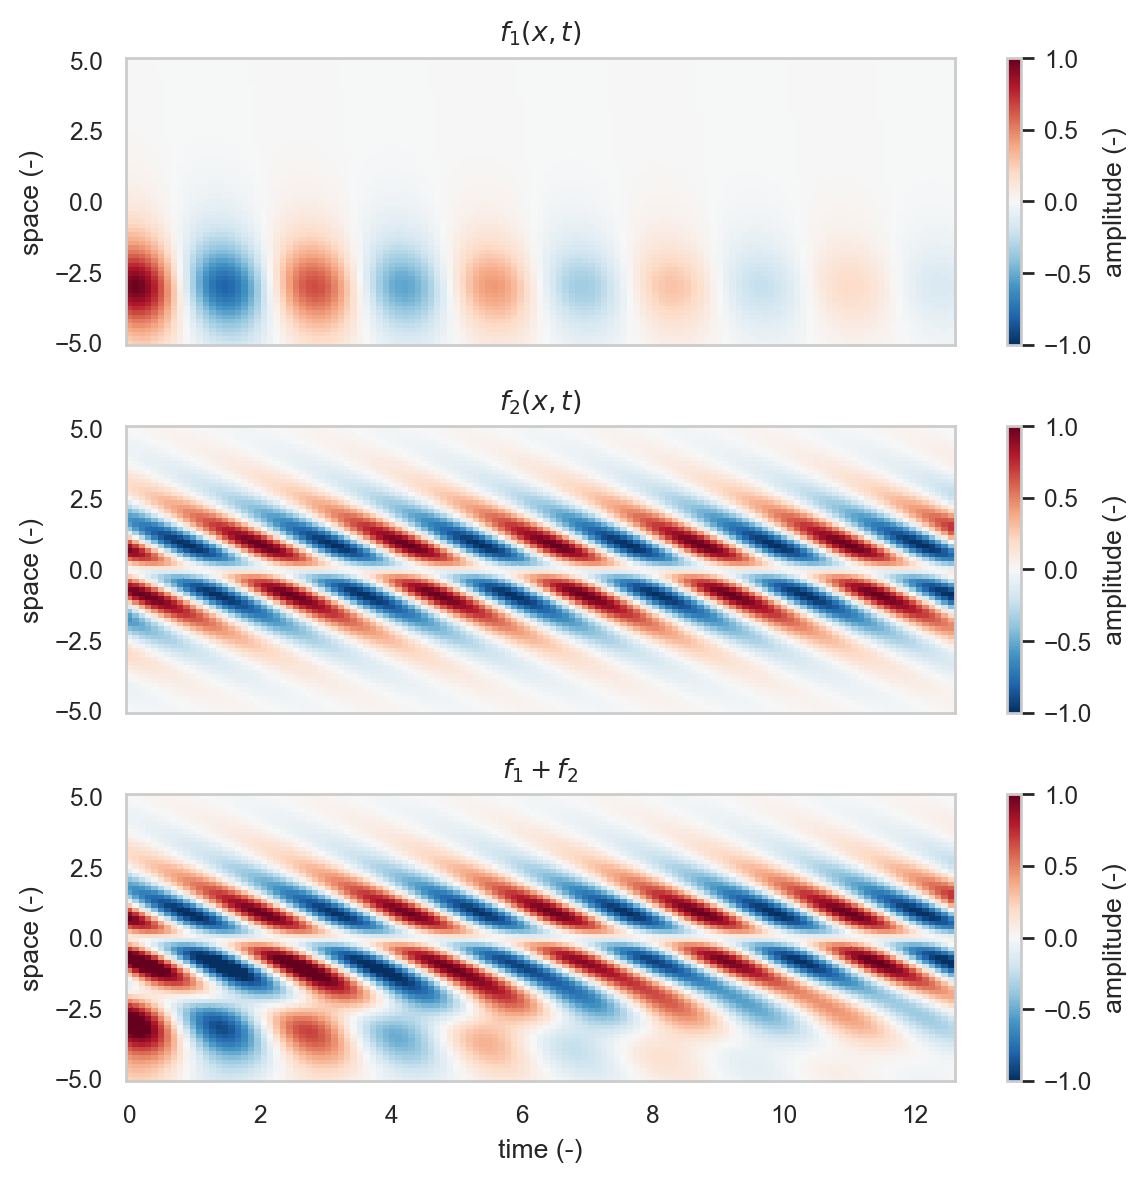

In [4]:
titles = ["$f_1(x,t)$", "$f_2(x,t)$", "$f_1 + f_2$"]
data = [X1, X2, X]

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
for n, (ax, title, d) in enumerate(zip(axes, titles, data, strict=True)):
    im = ax.pcolor(tgrid, xgrid, d.real, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(title)
    if n == 2:
        ax.set_xlabel("time (-)")
    ax.set_ylabel("space (-)")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("amplitude (-)")

fig.tight_layout()
plt.show()

Mode 1 is decaying.

# DMD

## Fit

We will perform three fits: one with a delay embedding (`delay_dmd`), one without (`dmd`), and one without delay embedding on centred data (also `dmd`). All use the variable-projection optimised DMD solver provided by `BOPDMD`.

In [5]:
d = 6  # we will use this number of delays throughout the tutorial
delay_dmd = BOPDMD(svd_rank=4, eig_constraints={"conjugate_pairs"})
delay_dmd = hankel_preprocessing(delay_dmd, d=d)

delay_t = t[: -d + 1] if d > 1 else t
delay_dmd.fit(X.T, t=delay_t)
print(f"Hankel + optDMD eigenvalues: {np.round(delay_dmd.eigs, decimals=2)}")

# Now let's do it again without a Hankel embedding.
dmd = BOPDMD(svd_rank=4, eig_constraints={"conjugate_pairs"})
dmd = hankel_preprocessing(dmd, d=1)
dmd.fit(X.T, t=t)
print(f"Optimised DMD, no Hankel eigenvalues: {np.round(dmd.eigs, decimals=2)}")

# And finally, optimised DMD with centred data.
dmd.fit(X.T - np.expand_dims(X.T.mean(axis=1), axis=1), t=t)
print(f"DMD eigenvalues after centring: {np.round(dmd.eigs, decimals=2)}")

Hankel + optDMD eigenvalues: [-0.  +2.8j -0.  -2.8j -0.15+2.3j -0.15-2.3j]
Optimised DMD, no Hankel eigenvalues: [ 0.  +2.8j  0.  -2.8j -0.15+2.3j -0.15-2.3j]
DMD eigenvalues after centring: [-0.  +2.8j -0.  -2.8j -0.15+2.3j -0.15-2.3j]


We recover perfectly the dynamics prescribed in $f_1$ and $f_2$. The real exponential decay for the 2nd mode is recovered. **THE EXPONENTIAL DECAY COULD NOT BE ACHIEVED WITH A DFT EQUIVALENT METHOD**. These results demonstrate how DMD and DFT are not equivalent generally.